In [3]:
import os
import gmsh
import numpy as np
import typing
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys 
from matplotlib.ticker import FormatStrFormatter
sys.path.append("./")

class SensorArray:
    def __init__(self,filename: str) -> None:
        data = np.loadtxt(filename,delimiter=",",skiprows=1)
        self.NumberDatapoints = np.size(data,0)
        self.NodeCoordinates = data[:,1:4]
        self.RealValue = data[:,4:7]
        self.ElementCoordinates = data[:,7:10]
    
    def getNodeCoordinates(self,idx:  typing.Optional[np.ndarray] = None) -> np.ndarray:
        if idx == None:
            return self.NodeCoordinates[:,:]
        else:
            if not np.issubdtype(idx.dtype, np.integer):  
                raise ValueError("Index array must contain integers.")

            if np.any(idx < 0) or np.any(idx >= self.NumberDatapoints):  
                raise IndexError("Index out of range.")
            
            return self.NodeCoordinates[idx, :]
        
    def getElementCoordinates(self,idx:  typing.Optional[np.ndarray] = None) -> np.ndarray:
        if idx == None:
            return self.ElementCoordinates[:,:]
        else:
            if not np.issubdtype(idx.dtype, np.integer):  
                raise ValueError("Index array must contain integers.")

            if np.any(idx < 0) or np.any(idx >= self.NumberDatapoints):  
                raise IndexError("Index out of range.")
            
            return self.ElementCoordinates[idx, :]
        
def OperaTable(filename):
    with open(filename, "r") as file:
        lines = file.readlines()
    
    # Dewtermine number of datapoints
    first_line = lines[0].strip()
    counts = list(map(int, first_line.split()))
    num_data_points = counts[0] * counts[1] * counts[2] 
    
    # Extract Header
    column_names = []
    for line in lines[1:]:
        line = line.strip()
        if line == "0":  # Ende des Headers
            break
        column_name = re.sub(r"^\d+\s+|\[.*?\]", "", line).strip() 
        column_names.append(column_name)
    
    # Get Data
    data_start_index = lines.index(" 0\n") + 1  # First index after row with "0\n"
    data_lines = lines[data_start_index:data_start_index + num_data_points]
    
    # Convert Data
    data = [list(map(float, line.split())) for line in data_lines]
    df = pd.DataFrame(data, columns=column_names)
    
    return df

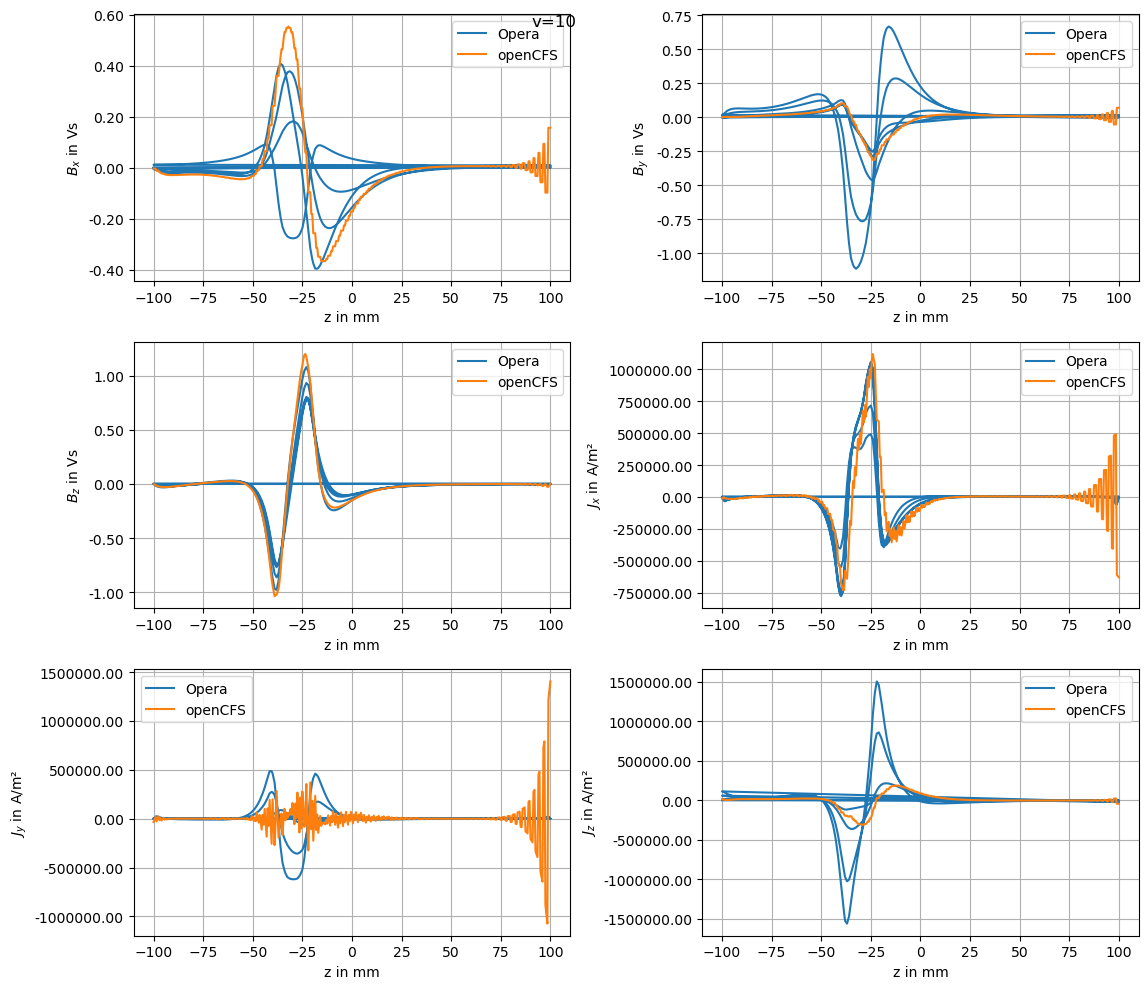

In [ ]:
v=10

openCFS_lineResult_Flux = SensorArray(f"sensorArray/flux_rail_v{v}.csv-1")
openCFS_lineResult_Current = SensorArray(f"sensorArray/current_rail_v{v}.csv-1")
opera_lineResults = OperaTable(f"OperaRes/coil_velocity_4_rail_{v}.table")

fig, ax = plt.subplots(3, 2, figsize=(12, 10))
ax = ax.flatten() 
for j, component in enumerate(["B_x", "B_y", "B_z", "J_x", "J_y", "J_z"]):
    
    ax[j].plot(1E3*opera_lineResults["Z"],opera_lineResults[component.replace("_", "")], linestyle='-',label=f"Opera")

    if j < 3: 
        cfsData = openCFS_lineResult_Flux
        unitStr = "Vs"
    elif j < 6: 
        cfsData = openCFS_lineResult_Current
        unitStr = "A/m²"

    cfsCoordinates = cfsData.getNodeCoordinates()
    ax.plot(1E3*cfsCoordinates[:,2],cfsData.RealValue[:,j%3], linestyle='-',label=f"openCFS")

    ax[j].set_xlabel("z in mm")
    ax[j].set_ylabel(f"${component}$ in {unitStr}")
    ax[j].grid()

    if j < 3:
        pass
    elif j <6:
        ax[j].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax[j].ticklabel_format(style='sci', axis='y', scilimits=(4,4))  # Erzwingt 1e4-Format

    ax[j].legend()
    ax[j].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    fig.tight_layout()
    fig.subplots_adjust(left=0.15)
fig.suptitle(f"v={v}")
fig.savefig(f"plots/v_{v}.pdf", dpi=300, bbox_inches="tight")
plt.show()

display a single plot:

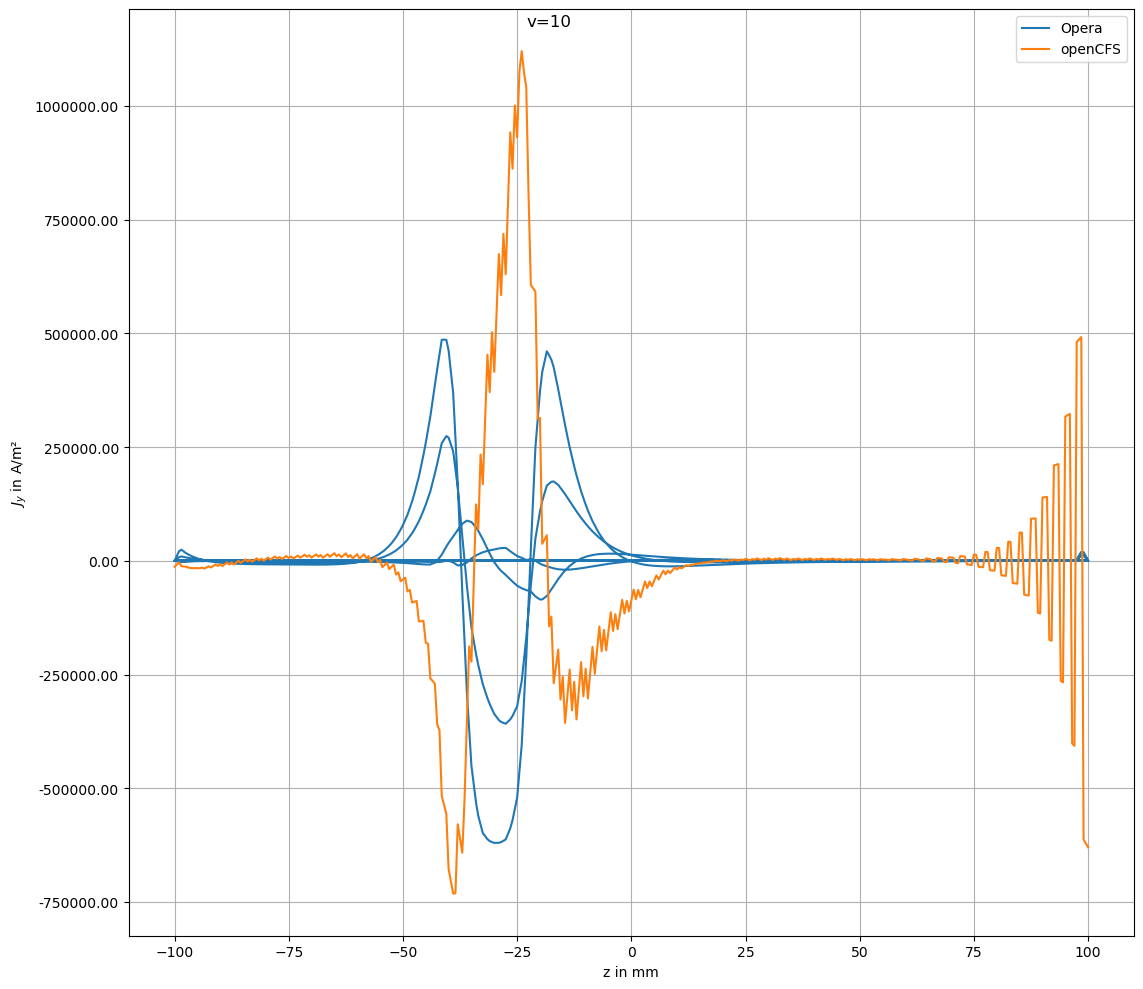

In [ ]:
v=10
# Read Sensor Array
openCFS_lineResult_Flux = SensorArray(f"sensorArray/flux_rail_v{v}.csv-1")
openCFS_lineResult_Current = SensorArray(f"sensorArray/current_rail_v{v}.csv-1")
opera_lineResults = OperaTable(f"OperaRes/coil_velocity_4_rail_{v}.table")

fig, ax = plt.subplots(figsize=(12, 10))
# for j, component in enumerate(["B_x", "B_y", "B_z", "J_x", "J_y", "J_z"]):
j=3
component="J_y"
ax.plot(1E3*opera_lineResults["Z"],opera_lineResults[component.replace("_", "")], linestyle='-',label=f"Opera")

if j < 3: 
    cfsData = openCFS_lineResult_Flux
    unitStr = "Vs"
elif j < 6: 
    cfsData = openCFS_lineResult_Current
    unitStr = "A/m²"

cfsCoordinates = cfsData.getNodeCoordinates()
ax.plot(1E3*cfsCoordinates[:,2],cfsData.RealValue[:,j%3], linestyle='-',label=f"openCFS")
ax.set_xlabel("z in mm")
ax.set_ylabel(f"${component}$ in {unitStr}")
ax.grid()

if j < 3:
    pass
elif j <6:
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(4,4))

ax.legend()
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
fig.tight_layout()
fig.subplots_adjust(left=0.15)
fig.suptitle(f"v={v}")
fig.savefig(f"plots/v_{v}.pdf", dpi=300, bbox_inches="tight")
plt.show()